# Классификация твитов: реальная катастрофа или нет
Проект по NLP (Kaggle «Getting Started»). Цель — предсказать `target` (1 = реальная катастрофа, 0 = нет).

План из 10 этапов реализован в виде модулей в `scripts/` и конфигурации в `configs/default.yaml`.

## Этап 0: Окружение и загрузка данных

In [1]:
import os
from sklearn.metrics import f1_score

os.chdir(os.path.abspath('..'))  # подняться из notebooks/ в корень

In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

from scripts.config import load_config
from scripts.data_loader import prepare_data

cfg = load_config('configs/default.yaml')
trn, tst, sample_submission = prepare_data(cfg)
print('trn:', trn.shape, '| tst:', tst.shape)
trn.head()

trn: (7613, 5) | tst: (3263, 4)


,id,keyword,location,text,target
0,1,nones,nones,Our Deeds are the Reason of this #earthquake M...,1
1,4,nones,nones,Forest fire near La Ronge Sask. Canada,1
2,5,nones,nones,All residents asked to 'shelter in place' are ...,1
3,6,nones,nones,"13,000 people receive #wildfires evacuation or...",1
4,7,nones,nones,Just got sent this photo from Ruby #Alaska as ...,1


## Этап 1: EDA

{'class_balance': target
0    4342
1    3271
Name: count, dtype: int64, 'missing_keyword_trn': np.float64(0.0), 'missing_keyword_tst': np.float64(0.0), 'missing_location_trn': np.float64(0.0), 'missing_location_tst': np.float64(0.0), 'keyword_cutoff_coverage': 0.04557992906869828}


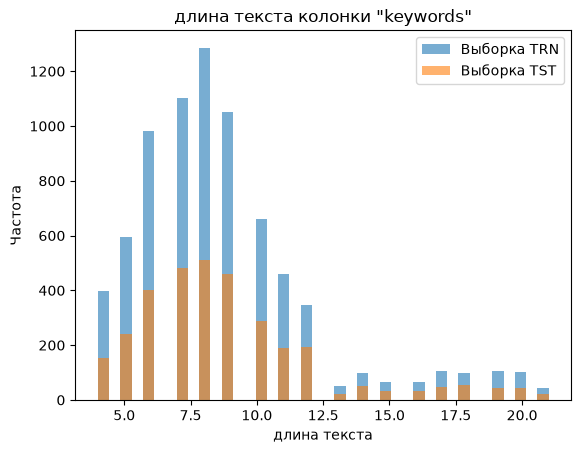

In [3]:
from scripts.eda import run_eda, plot_keyword_length
import matplotlib.pyplot as plt

info = run_eda(trn, tst, cfg)
print(info)
plot_keyword_length(trn, tst, cfg)
plt.show()

## Этап 2: Предобработка текста

In [4]:
from scripts.preprocess import preprocess_dataframe

trn = preprocess_dataframe(trn, cfg)
tst = preprocess_dataframe(tst, cfg)
trn[['text', 'clean_text']].head()

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deed are the reason of thi earthquak may a...
1,Forest fire near La Ronge Sask. Canada,forest fire near la rong sask canada
2,All residents asked to 'shelter in place' are ...,all resid ask to 'shelter in place are be noti...
3,"13,000 people receive #wildfires evacuation or...",peopl receiv wildfir evacu order in california
4,Just got sent this photo from Ruby #Alaska as ...,just got sent thi photo from rubi alaska as sm...


## Этап 3: Инженерия признаков

In [5]:
from scripts.features import add_text_features

trn = add_text_features(trn, cfg)
tst = add_text_features(tst, cfg)
numeric_cols = ['n_words', 'n_unique_words', 'n_upper', 'n_exclam', 'n_question', 'has_keyword']
trn[numeric_cols].head()

,n_words,n_unique_words,n_upper,n_exclam,n_question,has_keyword
0,13,13,10,0,0,0
1,7,7,5,0,0,0
2,22,20,2,0,0,0
3,8,8,1,0,0,0
4,16,15,3,0,0,0


## Этапы 4-6: Сплит, векторизация, обучение

In [6]:
from scripts.train import split_train_val, train_all
from scripts.vectorize import vectorize

trn_split, val = split_train_val(trn, cfg)
X_trn, X_val, pre = vectorize(trn_split, val, cfg, numeric_cols)
y_trn = trn_split[cfg.target_col]
y_val = val[cfg.target_col]

models = train_all(X_trn, y_trn, cfg)
print('Обучены:', list(models.keys()))

Обучены: ['logreg']


## Этапы 7-8: Оценка и анализ ошибок

In [7]:
from scripts.evaluate import evaluate_model, error_analysis

metrics = {}
for name, m in models.items():
    metrics[name] = evaluate_model(m, X_val, y_val)
    print(name, 'F1:', round(metrics[name]['f1'], 4))


logreg F1: 0.7608


## Этап 9: Submission

In [8]:
from scripts.predict import generate_submission, save_submission

best_model = models[max(metrics, key=lambda k: metrics[k]['f1'])]
_, X_tst, pre = vectorize(trn, tst, cfg, numeric_cols)  # refit на всём trn
sub = generate_submission(best_model, X_tst, sample_submission, cfg)
save_submission(sub, cfg)

Submission сохранён: data\submission.csv


## Этап 10: Сводная таблица

In [9]:
from scripts.report import build_summary
summary = build_summary(metrics)
summary

,model,f1,roc_auc,precision_1,recall_1
0,logreg,0.76082,0.870341,0.755656,0.766055


# Пробую взять эмбеддинг из HF

In [10]:
from transformers import BertTokenizer
# === Продолжение BERT-наброска (опционально, требует torch + transformers) ===
# Модель для классификации
from transformers import BertForSequenceClassification
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader
# Предсказание вероятностей на валидации
import torch.nn.functional as F
from sklearn.metrics import classification_report, roc_auc_score

c:\Users\User\Desktop\work_dir\Study DS\homeworks\HW_nlp_classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
tokenizer = BertTokenizer.from_pretrained(cfg.bert_model_name)

class TextDataset:
    def __init__(self, texts, labels, tokenizer, max_len=cfg.bert_max_len):
        self.texts, self.labels, self.tokenizer, self.max_len = texts, labels, tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], add_special_tokens=True,
                            truncation=True, max_length=self.max_len,
                            padding='max_length', return_attention_mask=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'labels': self.labels[idx]}


In [ ]:
# Подготовка данных (используем TextDataset из ячейки выше)
train_texts = trn_split['clean_text'].tolist()
train_labels = trn_split[cfg.target_col].tolist()
val_texts = val['clean_text'].tolist()
val_labels = val[cfg.target_col].tolist()

train_ds = TextDataset(train_texts, train_labels, tokenizer, max_len=cfg.bert_max_len)
val_ds = TextDataset(val_texts, val_labels, tokenizer, max_len=cfg.bert_max_len)
train_dl = DataLoader(train_ds, batch_size=cfg.bert_batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=cfg.bert_batch_size)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [41]:
from transformers import AutoTokenizer, AutoModel
import torch
# Sentences we want sentence embeddings for
sentences = list(trn.clean_text)

# Load model from HuggingFace Hub
tokenizer = AutoTokenizer.from_pretrained('BAAI/bge-large-en-v1.5')
model_hf = AutoModel.from_pretrained('BAAI/bge-large-en-v1.5')
model_hf.eval()

# Tokenize sentences
encoded_input = tokenizer(sentences, padding=True, truncation=True, return_tensors='pt')
# for s2p(short query to long passage) retrieval task, add an instruction to query (not add instruction for passages)
# encoded_input = tokenizer([instruction + q for q in queries], padding=True, truncation=True, return_tensors='pt')

# Compute token embeddings
with torch.no_grad():
    model_output = model_hf(**encoded_input)
    # Perform pooling. In this case, cls pooling.
    sentence_embeddings = model_output[0][:, 0]
# normalize embeddings
sentence_embeddings = torch.nn.functional.normalize(sentence_embeddings, p=2, dim=1)
print("Sentence embeddings:", sentence_embeddings)


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 8266.91it/s]


Sentence embeddings: tensor([[-0.0268,  0.0050, -0.0328,  ..., -0.0212, -0.0347,  0.0032],
        [ 0.0272,  0.0250, -0.0373,  ..., -0.0119,  0.0134,  0.0549],
        [-0.0317,  0.0177, -0.0395,  ..., -0.0522,  0.0480,  0.0043],
        ...,
        [ 0.0355,  0.0637,  0.0062,  ..., -0.0474, -0.0214,  0.0276],
        [-0.0450, -0.0054, -0.0447,  ..., -0.0106,  0.0285, -0.0256],
        [ 0.0225,  0.0300, -0.0226,  ..., -0.0284,  0.0020,  0.0181]])


In [42]:
# === Векторизация через BGE (HF transformers, без sentence_transformers) ===
# (замени 'zh' на 'en', если тексты английские)
def get_bge_embeddings(texts, tokenizer, model_hf, device="cpu"):
    model_hf.eval()
    enc = tokenizer(texts, padding=True, truncation=True,
                   max_length=128, return_tensors="pt").to(device)
    with torch.no_grad():
        out = model_hf(**enc)
    emb = out[0][:, 0]  # CLS pooling
    emb = torch.nn.functional.normalize(emb, p=2, dim=1)
    return emb.cpu().numpy()

model_hf.to(device)

# тексты уже подготовлены выше: train_texts, val_texts
X_trn_bge = get_bge_embeddings(train_texts, tokenizer, model_hf, device)
X_val_bge = get_bge_embeddings(val_texts, tokenizer, model_hf, device)

# === Классификатор поверх BGE (аналог "того же берта") ===
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, roc_auc_score, f1_score

class BGEClassifier(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc = nn.Linear(dim, 2)
    def forward(self, x):
        return self.fc(x)

Xtr = torch.tensor(X_trn_bge, dtype=torch.float32)
ytr = torch.tensor(train_labels, dtype=torch.long)
Xva = torch.tensor(X_val_bge, dtype=torch.float32)
yva = torch.tensor(val_labels, dtype=torch.long)

tr_ds = TensorDataset(Xtr, ytr)
va_ds = TensorDataset(Xva, yva)
tr_dl = DataLoader(tr_ds, batch_size=cfg.bert_batch_size, shuffle=True)
va_dl = DataLoader(va_ds, batch_size=cfg.bert_batch_size)

bge_model = BGEClassifier(X_trn_bge.shape[1]).to(device)
opt = torch.optim.AdamW(bge_model.parameters(), lr=cfg.bert_lr)
loss_fn = nn.CrossEntropyLoss()

In [43]:

for epoch in range(5):
    bge_model.train()
    tot = 0
    for xb, yb in tr_dl:
        opt.zero_grad()
        logits = bge_model(xb.to(device))
        loss = loss_fn(logits, yb.to(device))
        loss.backward(); opt.step()
        tot += loss.item()
    print(f"BGE epoch {epoch+1}, loss {tot/len(tr_dl):.4f}")

bge_model.eval()
probs, true = [], []
with torch.no_grad():
    for xb, yb in va_dl:
        p = torch.softmax(bge_model(xb.to(device)), dim=1)
        probs += p.cpu().tolist()
        true += yb.tolist()

probs_1 = [p[1] for p in probs]
preds = [1 if p >= 0.5 else 0 for p in probs_1]
print("=== BGE Embeddings Classification ===")
print(classification_report(true, preds))
print("ROC-AUC:", roc_auc_score(true, probs_1))
print("F1:", f1_score(true, preds))

BGE epoch 1, loss 0.6785
BGE epoch 2, loss 0.6574
BGE epoch 3, loss 0.6413
BGE epoch 4, loss 0.6269
BGE epoch 5, loss 0.6136
=== BGE Embeddings Classification ===
              precision    recall  f1-score   support

           0       0.71      0.97      0.82       869
           1       0.92      0.47      0.62       654

    accuracy                           0.75      1523
   macro avg       0.82      0.72      0.72      1523
weighted avg       0.80      0.75      0.73      1523

ROC-AUC: 0.8591037538314277
F1: 0.6199186991869918


Дообучаю

In [44]:
opt = torch.optim.AdamW(bge_model.parameters(), lr=0.0001)
for epoch in range(40):
    bge_model.train()
    tot = 0
    for xb, yb in tr_dl:
        opt.zero_grad()
        logits = bge_model(xb.to(device))
        loss = loss_fn(logits, yb.to(device))
        loss.backward(); opt.step()
        tot += loss.item()
    print(f"BGE epoch {epoch+1}, loss {tot/len(tr_dl):.4f}")

bge_model.eval()
probs, true = [], []
with torch.no_grad():
    for xb, yb in va_dl:
        p = torch.softmax(bge_model(xb.to(device)), dim=1)
        probs += p.cpu().tolist()
        true += yb.tolist()

BGE epoch 1, loss 0.5818
BGE epoch 2, loss 0.5421
BGE epoch 3, loss 0.5161
BGE epoch 4, loss 0.4979
BGE epoch 5, loss 0.4849
BGE epoch 6, loss 0.4753
BGE epoch 7, loss 0.4677
BGE epoch 8, loss 0.4620
BGE epoch 9, loss 0.4569
BGE epoch 10, loss 0.4528
BGE epoch 11, loss 0.4495
BGE epoch 12, loss 0.4464
BGE epoch 13, loss 0.4439
BGE epoch 14, loss 0.4415
BGE epoch 15, loss 0.4396
BGE epoch 16, loss 0.4376
BGE epoch 17, loss 0.4360
BGE epoch 18, loss 0.4344
BGE epoch 19, loss 0.4330
BGE epoch 20, loss 0.4315
BGE epoch 21, loss 0.4301
BGE epoch 22, loss 0.4293
BGE epoch 23, loss 0.4281
BGE epoch 24, loss 0.4271
BGE epoch 25, loss 0.4262
BGE epoch 26, loss 0.4253
BGE epoch 27, loss 0.4243
BGE epoch 28, loss 0.4236
BGE epoch 29, loss 0.4227
BGE epoch 30, loss 0.4220
BGE epoch 31, loss 0.4211
BGE epoch 32, loss 0.4205
BGE epoch 33, loss 0.4199
BGE epoch 34, loss 0.4192
BGE epoch 35, loss 0.4185
BGE epoch 36, loss 0.4180
BGE epoch 37, loss 0.4173
BGE epoch 38, loss 0.4164
BGE epoch 39, loss 0.

In [45]:
1

1

In [20]:
probs_1 = [p[1] for p in probs]
preds = [1 if p >= 0.5 else 0 for p in probs_1]
print("=== BGE Embeddings Classification ===")
print(classification_report(true, preds))
print("ROC-AUC:", roc_auc_score(true, probs_1))
print("F1:", f1_score(true, preds))

=== BGE Embeddings Classification ===
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       869
           1       0.83      0.74      0.79       654

    accuracy                           0.83      1523
   macro avg       0.83      0.82      0.82      1523
weighted avg       0.83      0.83      0.82      1523

ROC-AUC: 0.8761186361348944
F1: 0.7861178369652946


### 2. BERT
Ниже — заготовка `Dataset` для PyTorch/Transformers. Не запускается без `torch` и `transformers`.

In [46]:
model = BertForSequenceClassification.from_pretrained(cfg.bert_model_name, num_labels=2)
model.to(device);

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4286.39it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

In [47]:

# Оптимизатор
opt = AdamW(model.parameters(), lr=cfg.bert_lr)

# Цикл обучения (упрощённый)
for epoch in range(5):
    model.train()
    tot_loss = 0
    for batch in train_dl:
        opt.zero_grad()
        inp = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        lbl = batch['labels'].to(device)
        out = model(**inp, labels=lbl)
        loss = out.loss
        loss.backward()
        opt.step()
        tot_loss += loss.item()
    print(f'epoch {epoch+1}, loss {tot_loss/len(train_dl):.4f}')

# Предсказание на валидации
model.eval()
preds, true = [], []
with torch.no_grad():
    for batch in val_dl:
        inp = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        logits = model(**inp).logits
        preds += logits.argmax(dim=1).cpu().tolist()
        true += batch['labels'].tolist()

from sklearn.metrics import classification_report
print(classification_report(true, preds))


epoch 1, loss 0.4889
epoch 2, loss 0.3653
epoch 3, loss 0.2575
epoch 4, loss 0.1727
epoch 5, loss 0.1162
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       869
           1       0.78      0.79      0.78       654

    accuracy                           0.81      1523
   macro avg       0.81      0.81      0.81      1523
weighted avg       0.81      0.81      0.81      1523



In [48]:
print("F1:", f1_score(true, preds))

F1: 0.7844630616907845


Дообучаю 

In [49]:
save_path = "models/bert_classifier"

In [50]:
# Цикл обучения (упрощённый)
for epoch in range(13):
    model.train()
    tot_loss = 0
    for batch in train_dl:
        opt.zero_grad()
        inp = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        lbl = batch['labels'].to(device)
        out = model(**inp, labels=lbl)
        loss = out.loss
        loss.backward()
        opt.step()
        tot_loss += loss.item()
    model.save_pretrained(save_path)
    tokenizer.save_pretrained(save_path)
    print(f'epoch {epoch+1}, loss {tot_loss/len(train_dl):.4f}')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.10it/s]


epoch 1, loss 0.0983


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.53it/s]


epoch 2, loss 0.0767


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.72it/s]


...

epoch 11, loss 0.0593


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.89it/s]


epoch 12, loss 0.0470


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.70it/s]

epoch 13, loss 0.0519


In [51]:
model.eval()
probs, true = [], []
with torch.no_grad():
    for batch in val_dl:
        inp = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        logits = model(**inp).logits
        # softmax по dim=1 -> вероятности классов [p0, p1]
        batch_probs = F.softmax(logits, dim=1)
        probs += batch_probs.cpu().tolist()           # список списков [[p0,p1], ...]
        true += batch['labels'].tolist()

# вероятность класса 1 (катастрофа)
probs_1 = [p[1] for p in probs]


In [52]:

print(classification_report(true, [1 if p >= 0.5 else 0 for p in probs_1]))
print("ROC-AUC:", roc_auc_score(true, probs_1))
print("F1:", f1_score(true, [1 if p >= 0.5 else 0 for p in probs_1]))


              precision    recall  f1-score   support

           0       0.82      0.84      0.83       869
           1       0.78      0.76      0.77       654

    accuracy                           0.80      1523
   macro avg       0.80      0.80      0.80      1523
weighted avg       0.80      0.80      0.80      1523

ROC-AUC: 0.8494200511678156
F1: 0.768160741885626


Результаты Берта получился хуже

## 3. Готовая модель - взять полученные из модели эмбеддинги и дообучить на своей задаче

Загрузка DistilBERT и получение эмбеддингов

In [53]:
import numpy as np

In [54]:
from transformers import AutoTokenizer, AutoModel
import torch

# Готовая модель (предобученная, без головы классификации)
emb_name = "distilbert-base-uncased"
tok_dist = AutoTokenizer.from_pretrained(emb_name)
dist_model = AutoModel.from_pretrained(emb_name)
dist_model.eval().to(device)

def get_distilbert_embeddings(texts, tokenizer, model, max_len=128):
    """Берём эмбеддинг [CLS]-аналога (в DistilBERT это первый токен)"""
    out = []
    for t in texts:
        inp = tokenizer(t, return_tensors="pt", truncation=True,
                        max_length=max_len, padding=True).to(device)
        with torch.no_grad():
            h = model(**inp).last_hidden_state
        # первый токен (cls) как агрегация
        out.append(h[:, 0, :].cpu().numpy()[0])
    return np.array(out)

# тексты уже есть: train_texts, val_texts
X_trn_dist = get_distilbert_embeddings(train_texts, tok_dist, dist_model)
X_val_dist = get_distilbert_embeddings(val_texts, tok_dist, dist_model)

c:\Users\User\Desktop\work_dir\Study DS\homeworks\HW_nlp_classification\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\User\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 9667.19it/s]


Дообучаемый классификатор поверх эмбеддингов

In [73]:
cfg.bert_batch_size = 20

In [75]:
class EmbedClassifier(nn.Module):
    def __init__(self, dim, n_classes=2):
        super().__init__()
        self.fc = nn.Linear(dim, n_classes)
    def forward(self, x):
        return self.fc(x)

Xtr = torch.tensor(X_trn_dist, dtype=torch.float32)
ytr = torch.tensor(train_labels, dtype=torch.long)
Xva = torch.tensor(X_val_dist, dtype=torch.float32)
yva = torch.tensor(val_labels, dtype=torch.long)

tr_ds = TensorDataset(Xtr, ytr)
va_ds = TensorDataset(Xva, yva)
tr_dl = DataLoader(tr_ds, batch_size=cfg.bert_batch_size, shuffle=True)
va_dl = DataLoader(va_ds, batch_size=cfg.bert_batch_size)

clf = EmbedClassifier(X_trn_dist.shape[1]).to(device)
opt = torch.optim.AdamW(clf.parameters(), lr=cfg.bert_lr)
loss_fn = nn.CrossEntropyLoss()

# Дообучение на своей задаче
for epoch in range(120):
    clf.train(); tot = 0
    for xb, yb in tr_dl:
        opt.zero_grad()
        loss = loss_fn(clf(xb.to(device)), yb.to(device))
        loss.backward(); opt.step()
        tot += loss.item()
    print(f"DistilBERT-emb epoch {epoch+1}, loss {tot/len(tr_dl):.4f}")

DistilBERT-emb epoch 1, loss 0.6751
DistilBERT-emb epoch 2, loss 0.6489
DistilBERT-emb epoch 3, loss 0.6288
DistilBERT-emb epoch 4, loss 0.6120
DistilBERT-emb epoch 5, loss 0.5981
DistilBERT-emb epoch 6, loss 0.5859
DistilBERT-emb epoch 7, loss 0.5756
DistilBERT-emb epoch 8, loss 0.5671
DistilBERT-emb epoch 9, loss 0.5594
DistilBERT-emb epoch 10, loss 0.5529
DistilBERT-emb epoch 11, loss 0.5473
DistilBERT-emb epoch 12, loss 0.5419
DistilBERT-emb epoch 13, loss 0.5376
DistilBERT-emb epoch 14, loss 0.5336
DistilBERT-emb epoch 15, loss 0.5298
DistilBERT-emb epoch 16, loss 0.5268
DistilBERT-emb epoch 17, loss 0.5234
DistilBERT-emb epoch 18, loss 0.5215
DistilBERT-emb epoch 19, loss 0.5188
DistilBERT-emb epoch 20, loss 0.5157
DistilBERT-emb epoch 21, loss 0.5135
DistilBERT-emb epoch 22, loss 0.5117
DistilBERT-emb epoch 23, loss 0.5097
DistilBERT-emb epoch 24, loss 0.5082
DistilBERT-emb epoch 25, loss 0.5065
DistilBERT-emb epoch 26, loss 0.5051
DistilBERT-emb epoch 27, loss 0.5039
DistilBERT

In [77]:
# Дообучение на своей задаче
for epoch in range(500):
    clf.train(); tot = 0
    for xb, yb in tr_dl:
        opt.zero_grad()
        loss = loss_fn(clf(xb.to(device)), yb.to(device))
        loss.backward(); opt.step()
        tot += loss.item()
    print(f"DistilBERT-emb epoch {epoch+1}, loss {tot/len(tr_dl):.4f}")

DistilBERT-emb epoch 1, loss 0.4615
DistilBERT-emb epoch 2, loss 0.4615
DistilBERT-emb epoch 3, loss 0.4619
DistilBERT-emb epoch 4, loss 0.4614
DistilBERT-emb epoch 5, loss 0.4610
DistilBERT-emb epoch 6, loss 0.4611
DistilBERT-emb epoch 7, loss 0.4606
DistilBERT-emb epoch 8, loss 0.4604
DistilBERT-emb epoch 9, loss 0.4602
DistilBERT-emb epoch 10, loss 0.4608
DistilBERT-emb epoch 11, loss 0.4600
DistilBERT-emb epoch 12, loss 0.4602
DistilBERT-emb epoch 13, loss 0.4600
DistilBERT-emb epoch 14, loss 0.4596
DistilBERT-emb epoch 15, loss 0.4597
DistilBERT-emb epoch 16, loss 0.4593
DistilBERT-emb epoch 17, loss 0.4596
DistilBERT-emb epoch 18, loss 0.4591
DistilBERT-emb epoch 19, loss 0.4590
DistilBERT-emb epoch 20, loss 0.4586
DistilBERT-emb epoch 21, loss 0.4588
DistilBERT-emb epoch 22, loss 0.4590
DistilBERT-emb epoch 23, loss 0.4582
DistilBERT-emb epoch 24, loss 0.4583
DistilBERT-emb epoch 25, loss 0.4579
DistilBERT-emb epoch 26, loss 0.4579
DistilBERT-emb epoch 27, loss 0.4579
DistilBERT

Оценка

In [78]:
clf.eval(); probs, true = [], []
with torch.no_grad():
    for xb, yb in va_dl:
        p = torch.softmax(clf(xb.to(device)), dim=1)
        probs += p.cpu().tolist()
        true += yb.tolist()

probs_1 = [p[1] for p in probs]
preds = [1 if p >= 0.5 else 0 for p in probs_1]
print("=== DistilBERT embeddings + head ===")
print(classification_report(true, preds))
print("ROC-AUC:", roc_auc_score(true, probs_1))
print("F1:", f1_score(true, preds))

=== DistilBERT embeddings + head ===
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       869
           1       0.82      0.71      0.76       654

    accuracy                           0.81      1523
   macro avg       0.81      0.79      0.80      1523
weighted avg       0.81      0.81      0.80      1523

ROC-AUC: 0.8621530600394843
F1: 0.7577741407528642


In [ ]:
clf.eval(); probs, true = [], []
with torch.no_grad():
    for xb, yb in va_dl:
        p = torch.softmax(clf(xb.to(device)), dim=1)
        probs += p.cpu().tolist()
        true += yb.tolist()

probs_1 = [p[1] for p in probs]
preds = [1 if p >= 0.5 else 0 for p in probs_1]
print("=== DistilBERT embeddings + head ===")
print(classification_report(true, preds))
print("ROC-AUC:", roc_auc_score(true, probs_1))
print("F1:", f1_score(true, preds))

=== DistilBERT embeddings + head ===
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       869
           1       0.82      0.71      0.76       654

    accuracy                           0.81      1523
   macro avg       0.81      0.79      0.80      1523
weighted avg       0.81      0.81      0.80      1523

ROC-AUC: 0.8621530600394843
F1: 0.7577741407528642


## 4. Дообучаю модель BERT - Fine Tuning 

In [100]:
# Подготовка данных (используем TextDataset из ячейки выше)
train_texts = trn_split['clean_text'].tolist()
train_labels = trn_split[cfg.target_col].tolist()
val_texts = val['clean_text'].tolist()
val_labels = val[cfg.target_col].tolist()

train_ds = TextDataset(train_texts, train_labels, tokenizer, max_len=cfg.bert_max_len)
val_ds = TextDataset(val_texts, val_labels, tokenizer, max_len=cfg.bert_max_len)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32)

In [101]:
model = BertForSequenceClassification.from_pretrained(cfg.bert_model_name, num_labels=2)
model.to(device)

# --- Разморозка последних N слоёв (пример: 3 слоя) ---
N_UNFREEZE = 3

# 1. Заморозить всё
for param in model.parameters():
    param.requires_grad = False

# 2. Разморозить последние N encoder-слоёв
for layer in model.bert.encoder.layer[-N_UNFREEZE:]:
    for param in layer.parameters():
        param.requires_grad = True

# 3. Разморозить классификационную голову (всегда)
for param in model.classifier.parameters():
    param.requires_grad = True

# Проверка: сколько параметров обучается
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8544.99it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoi

Trainable params: 21,265,154


In [107]:
# --- Обучение (тот же цикл, но lr поменьше) ---
opt = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    # lr=cfg.bert_lr
    lr=cfg.bert_lr * 0.1   # меньше, т.к. дообучаем часть
)


In [103]:
from tqdm.auto import tqdm

In [111]:

for epoch in range(100):
    model.train()
    tot_loss = 0
    for batch in train_dl:
        opt.zero_grad()
        inp = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        lbl = batch['labels'].to(device)
        out = model(**inp, labels=lbl)
        loss = out.loss
        loss.backward()
        opt.step()
        tot_loss += loss.item()
    print(f'epoch {epoch+1}, loss {tot_loss/len(train_dl):.4f}')

epoch 1, loss 0.0298
epoch 2, loss 0.0256
epoch 3, loss 0.0288
epoch 4, loss 0.0294
epoch 5, loss 0.0261
epoch 6, loss 0.0283
epoch 7, loss 0.0279
epoch 8, loss 0.0296
epoch 9, loss 0.0288
epoch 10, loss 0.0272
epoch 11, loss 0.0277
epoch 12, loss 0.0328
epoch 13, loss 0.0306
epoch 14, loss 0.0280
epoch 15, loss 0.0270
epoch 16, loss 0.0285
epoch 17, loss 0.0258
epoch 18, loss 0.0249
epoch 19, loss 0.0264
epoch 20, loss 0.0301
epoch 21, loss 0.0276
epoch 22, loss 0.0281
epoch 23, loss 0.0291
epoch 24, loss 0.0280
epoch 25, loss 0.0281
epoch 26, loss 0.0261
epoch 27, loss 0.0274
epoch 28, loss 0.0267
epoch 29, loss 0.0289
epoch 30, loss 0.0262
epoch 31, loss 0.0262
epoch 32, loss 0.0268
epoch 33, loss 0.0286
epoch 34, loss 0.0249
epoch 35, loss 0.0278
epoch 36, loss 0.0284
epoch 37, loss 0.0261
epoch 38, loss 0.0267
epoch 39, loss 0.0262
epoch 40, loss 0.0265
epoch 41, loss 0.0285
epoch 42, loss 0.0274
epoch 43, loss 0.0264
epoch 44, loss 0.0271
epoch 45, loss 0.0277
epoch 46, loss 0.02

In [112]:
# Предсказание на валидации
model.eval()
probs, true = [], []
with torch.no_grad():
    for batch in val_dl:
        inp = {k: v.to(device) for k, v in batch.items() if k != 'labels'}
        logits = model(**inp).logits
        # softmax -> вероятности классов [p0, p1]
        batch_probs = F.softmax(logits, dim=1)
        probs += batch_probs.cpu().tolist()
        true += batch['labels'].tolist()

# вероятность класса 1 (катастрофа)
probs_1 = [p[1] for p in probs]
# если нужны сами предсказания из вероятностей
preds = [1 if p >= 0.5 else 0 for p in probs_1]

from sklearn.metrics import classification_report
print(classification_report(true, preds))
print("ROC-AUC:", roc_auc_score(true, probs_1))
print("F1:", f1_score(true, preds))

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       869
           1       0.78      0.76      0.77       654

    accuracy                           0.80      1523
   macro avg       0.80      0.80      0.80      1523
weighted avg       0.80      0.80      0.80      1523

ROC-AUC: 0.8647123305989872
F1: 0.7692307692307693
